# Description
In this notebook, we will run a PCA mean-reversion strategy, similar to equity stat arb. The exact methodology will be the following. First, we will perform rolling PCA on daily returns using a window size of $W$ observations. The idea is to wait until we have $W$ observations, and then only save the PCs computed for the last day in the window. To illustrate, suppose for example that $W=252$. The first fit will be on the first $252$ days, and we save the result for the last day. The next fit will be from day $2$ to day $253$, and we save the result from the last day, and so on. We are doing this to avoid data leakage. If we used the whole series, then the PCs defined earlier depend on future values of the returns, and this is not available when  performing a trading algorithm. After computing PCs, we will regress daily returns on the Principal Components. From this point, we will either assign directional positions, or cross-sectional positions based on the forecasted value, or the residual. Regarding the residual, we want to perform mean-reversion. This means that if the return is larger than the predicted value, we go short. Otherwise, we go long. Initially, we will use an equal weight portfolio. Unless specifically mentioned, we will use the close price to calculate returns.

# Import

In [1]:
# Standard library imports
import sys
import datetime as dt

# Third party applications imports
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
plt.style.use("seaborn-v0_8")

# Local imports
from utilities import (simple_returns, log_returns, directional_positions, cross_sectional_positions, position_returns, date_returns, calculate_sr, calculate_wealth, cum_simple_wealth, cum_log_wealth, adf_fuller_test, multiple_adf_tests)
from ar_script import rolling_regression, multiple_apply_regression
from pca_script import rolling_pca

# Data Preparation

In [2]:
# Read the date
df_prices = (
    pd.read_csv('df_train.csv',
                parse_dates=['date'])
    .sort_values(by='date', ascending=True) # Ensure it is sorted
)

# Filter for the training dates
END_DATE = "2012-01-01"
df_train = df_prices[df_prices['date'] < END_DATE]

# Pivot to wide
df_train_wide = df_train.pivot(index='date', values='close', columns='symbol').sort_index()

# Calculate simple daily returns 
K_STEP_RETURNS = 1
df_train_returns = simple_returns(df_train_wide, K_STEP_RETURNS)

# PCA analysis
As illustrated in the <code>AR1Analysis.ipynb</code> notebook, daily simple returns are stationary, so we can safely perform PCA on them. The first step is to see how many components explain a certain amount of variation. We will start with $3$ components, and see whether we are satisfied.

In [3]:
# Initiate PCA
NB_COMPONENTS = 3
pca_rets = PCA(n_components=NB_COMPONENTS)

# Calculate PCs on returns
Z = pca_rets.fit_transform(df_train_returns)
# Show PCs as a dataframe
df_z = pd.DataFrame(Z, columns=[f'PC{i}' for i in range(1, NB_COMPONENTS+1)], index=df_train_returns.index)

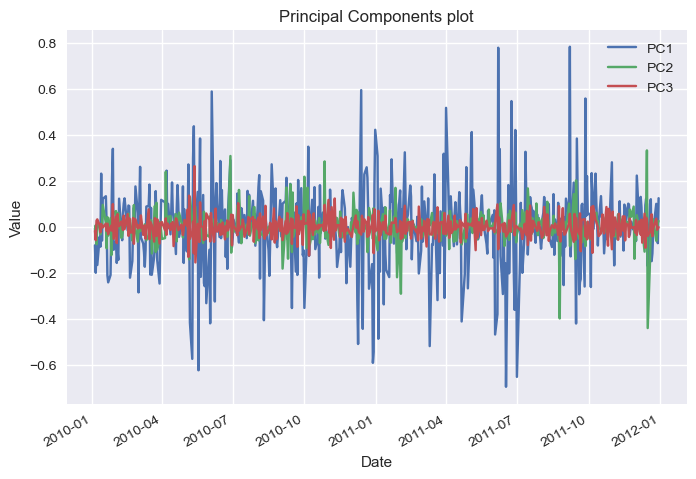

In [4]:
# Plot the principal components
for col in df_z.columns:
    df_z[col].plot()
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.title('Principal Components plot')
plt.show()

In [5]:
# Find the explained Variance Ratio
explained_vars = pd.DataFrame({'explained_var_ratio': pca_rets.explained_variance_ratio_,
                               'PC': df_z.columns})
explained_vars

,explained_var_ratio,PC
0,0.551948,PC1
1,0.070814,PC2
2,0.033069,PC3


We can observe that the first $3$ PCs explain around $68$% of variation in the data. We can try using more PCs, but they lose their interpretation, and they might fit to noise. As a check, we will run the full PCA to see a scree plot. The full PCA has 100 components, since there are 100 assets.

In [6]:
# Initiate PCA full
NB_COMPONENTS_FULL = 100
pca_full = PCA(n_components=NB_COMPONENTS_FULL)

# Apply full PCA on the returns
Z_full_pca = pca_full.fit_transform(df_train_returns)

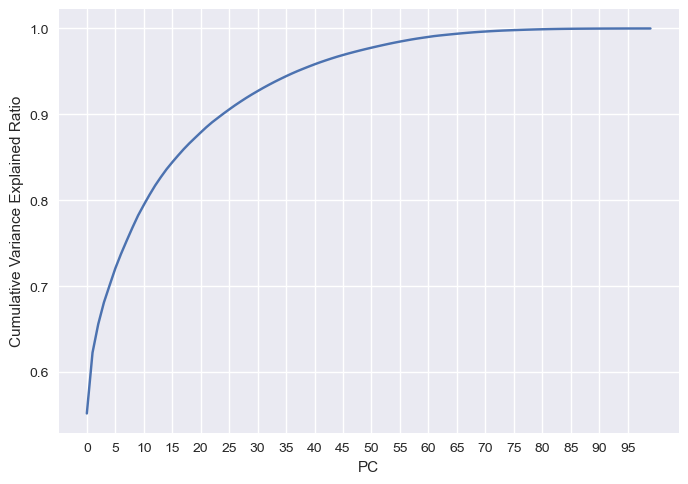

In [7]:
# Find the cumulative explained variance proportion
cum_explained_full_var = np.cumsum(pca_full.explained_variance_ratio_)
idx = np.arange(len(cum_explained_full_var))
plt.plot(idx, cum_explained_full_var)
plt.xticks(np.arange(0, len(cum_explained_full_var), step=5))
plt.xlabel('PC')
plt.ylabel('Cumulative Variance Explained Ratio')
plt.show()

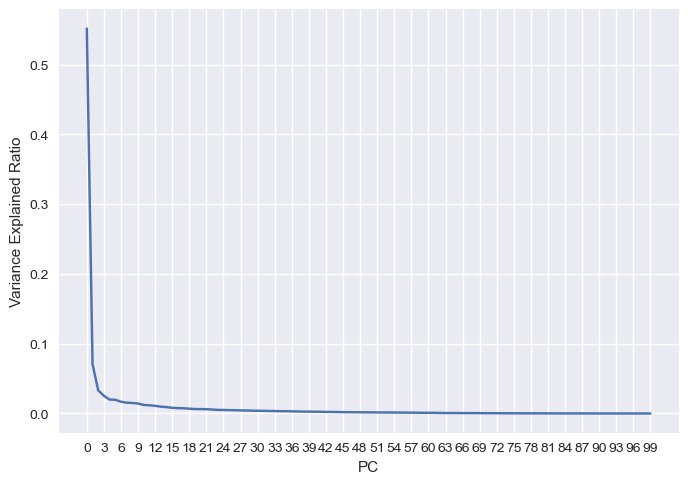

In [8]:
# Find the explained variance of each PC
individ_explained_var = pca_full.explained_variance_ratio_
idx_individ = np.arange(len(individ_explained_var))
plt.plot(idx_individ, individ_explained_var)
plt.xticks(np.arange(0, len(individ_explained_var), step=3))
plt.xlabel('PC')
plt.ylabel('Variance Explained Ratio')
plt.show()

In [9]:
# Dataframe with both individual explained var ratio and cumulative explained var ratio
df_individ_var = pd.DataFrame({'explained_var_ratio': individ_explained_var,
                               'cumulative_explaine_var': cum_explained_full_var,
                               'PC': [f'PC{i}' for i in range(1, NB_COMPONENTS_FULL+1)]})
df_individ_var

,explained_var_ratio,cumulative_explaine_var,PC
0,0.551948,0.551948,PC1
1,0.070814,0.622762,PC2
2,0.033069,0.655831,PC3
3,0.025327,0.681158,PC4
4,0.019911,0.701069,PC5
...,...,...,...
95,0.000015,0.999971,PC96
96,0.000011,0.999982,PC97
97,0.000007,0.999989,PC98
98,0.000006,0.999995,PC99


We can observe that 4 PCs capture about $70$% in the variance of the returns. It is usually advisable to look for an elbow in the scree plot (heuristic method), and this elbow happend around the third PC. Therefore, we will use $3$ PCs to avoid overfitting.

# Rolling PCA computation
In this part of the notebook, we will perform rolling PCA computation. Initially, we will choose the fitting window to be $W=126$, which is half a year. Usually, it is recommended to have a larger window, but given the size of the dataset, we do not afford that luxury.


In [10]:
# Fitting window
W_PCA = 126
ROLLING_PCA_COMPONENTS = 3

# Calculate Principal Components
rolling_pcs = rolling_pca(df_train_returns, 
                          nb_components=ROLLING_PCA_COMPONENTS,
                          w=W_PCA)

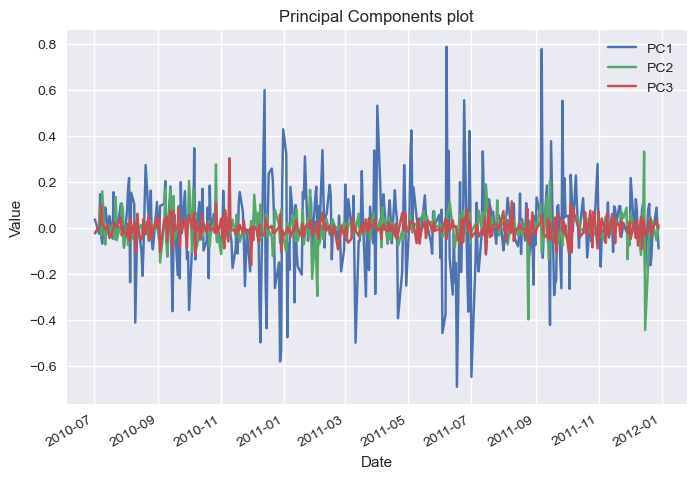

In [11]:
# Plot the principal components
for col in rolling_pcs.columns:
    rolling_pcs[col].plot()
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.title('Principal Components plot')
plt.show()

# PC Regression
In this part of the notebook, we will regress each instrument forward return on lagged Principal Components. Specifically, the regressions will have the form $$r_{i,t} = \beta_{i,0} + \beta_{i,1}p_{1,t-1} + \beta_{i,2}p_{2,t-1} + \beta_{i,3}p_{3,t-1} + \eta_{t},$$
where the coefficients are to be estimated using rolling regression. We then forecast the next day return. Subsequently, we will instantiate positions based on these forecasted values.

In [12]:
# Calculate forward returns
K_FORWARD_RETURNS = 1
train_forward_returns = df_train_returns.shift(-K_FORWARD_RETURNS).dropna()

In [13]:
# Join PCs with forward returns
pcs_returns = rolling_pcs.join(train_forward_returns, how='inner')

# Find symbols
symbols = sorted(df_train['symbol'].unique().tolist())

# Regression fitting window
W_PCS_RETS = 126

# Identify PCA features
pca_features = [f'PC{i}' for i in range(1, ROLLING_PCA_COMPONENTS+1)]

# Identify model
model_lr = LinearRegression()

# Fit PC regression and generate forecasts
pc_rets_reg = multiple_apply_regression(pcs_returns, symbols, pca_features, model_lr, w=W_PCS_RETS, k=K_FORWARD_RETURNS)



In [14]:
# Empty list to hold renamed dfs
new_dfs = []
for i, symb in enumerate(symbols):
    curr_pc_forecast = pc_rets_reg[i].copy()
    curr_pc_forecast = curr_pc_forecast.rename(columns={symb: 'return'})
    curr_pc_forecast['symbol'] = symb
    curr_pc_forecast['fwd_return'] = curr_pc_forecast['return'].shift(-K_FORWARD_RETURNS)
    new_dfs.append(curr_pc_forecast)
all_pc_forecasts = pd.concat(new_dfs, axis=0).sort_index().dropna()

In [15]:
all_pc_forecasts

,forecast,return,symbol,fwd_return
date,,,,
2011-01-03,0.007663,-0.064103,ACTS,-0.022562
2011-01-03,0.013299,-0.068681,FBR,-0.011799
2011-01-03,0.005413,-0.040462,WSM,-0.012048
2011-01-03,0.011797,-0.070175,FJX,0.037736
2011-01-03,0.002499,-0.076336,GCD,-0.016043
...,...,...,...,...
2011-12-28,0.001580,0.000000,FJX,0.016729
2011-12-28,0.000777,-0.000966,KXRV,0.005803
2011-12-28,0.002141,-0.021493,RYX,0.015029


# Strategies

### Strategy 1: assign cross-sectional positions based on forecasted values
In this strategy, we will rank instruments by their forecasted return values. We will then go long the $k$ instruments with the largest forecasted values and short the $k$ instruments with the lowest forecasted values. Initially, $k=5$.

In [16]:
# Assign cross-sectional positions based on rankings of forecasts
pc_forecast_cross = cross_sectional_positions(all_pc_forecasts, 'forecast', 2)

#Calculate returns
pc_forecast_cs_ret = position_returns(pc_forecast_cross, 'weight', 'return')
pc_forecast_cs_date_rets = date_returns(pc_forecast_cs_ret, 'positions_return')
pc_forecast_cs_sr = calculate_sr(pc_forecast_cs_date_rets, 'positions_return')
pc_forecast_cross_wealth = calculate_wealth(pc_forecast_cs_date_rets, 'positions_return')
pc_forecast_log_w = cum_log_wealth(pc_forecast_cross_wealth, 'wealth')
pc_forecast_cum_w = cum_simple_wealth(pc_forecast_log_w, 'wealth')
print('Daily SR:', pc_forecast_cs_sr)

Daily SR: 0.14151212354761378


In [17]:
pc_forecast_cum_w

,positions_return,wealth,log_cum_wealth,cum_wealth
date,,,,
2011-01-03,-0.001709,0.998291,-0.001710,0.998291
2011-01-04,-0.000379,0.999621,-0.002089,0.997913
2011-01-05,0.010070,1.010070,0.007930,1.007962
2011-01-06,-0.000713,0.999287,0.007217,1.007243
2011-01-07,0.011875,1.011875,0.019022,1.019204
...,...,...,...,...
2011-12-21,0.017463,1.017463,0.782429,2.186777
2011-12-22,-0.051489,0.948511,0.729567,2.074183
2011-12-23,0.027459,1.027459,0.756656,2.131138


### Strategy 2: assign cross-sectional positions based on residual values
In this strategy, we will rank instruments by their negative residuals. We will then go long the $k$ instruments with the lowest residual values and short the $k$ instruments with the highest residual values. Initially, $k=5$.

In [18]:
# Create residuals
pc_forecasts_resids = all_pc_forecasts.copy()
pc_forecasts_resids['residual'] = all_pc_forecasts['forecast'] - all_pc_forecasts['return']

# Assign cs positions based on rakings of the negative residual
pc_forecast_resid_cross = cross_sectional_positions(pc_forecasts_resids, 'residual', 2)

# Calculate returns
pc_forecast_cs_resid_ret = position_returns(pc_forecast_resid_cross, 'weight', 'fwd_return')
pc_forecast_cs_date_resid_rets = date_returns(pc_forecast_cs_resid_ret, 'positions_return')
pc_forecast_cs_resid_sr = calculate_sr(pc_forecast_cs_date_resid_rets, 'positions_return')
pc_forecast_resid_cross_wealth = calculate_wealth(pc_forecast_cs_date_resid_rets, 'positions_return')
pc_forecast_resid_log_w = cum_log_wealth(pc_forecast_resid_cross_wealth, 'wealth')
pc_forecast_resid_cum_w = cum_simple_wealth(pc_forecast_resid_log_w, 'wealth')
print('Daily SR:', pc_forecast_cs_resid_sr)

Daily SR: 0.25868178223478294


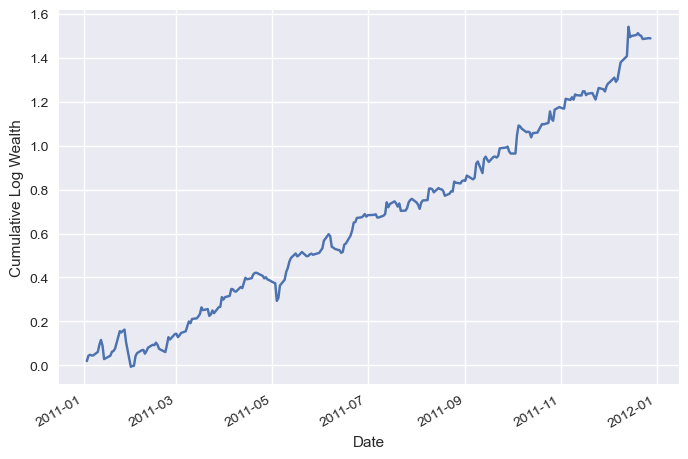

In [19]:
pc_forecast_resid_cum_w['log_cum_wealth'].plot()
plt.xlabel('Date')
plt.ylabel('Cumulative Log Wealth')
plt.show()

In [20]:
pc_forecast_resid_cum_w

,positions_return,wealth,log_cum_wealth,cum_wealth
date,,,,
2011-01-03,0.020206,1.020206,0.020005,1.020206
2011-01-04,0.024265,1.024265,0.043980,1.044961
2011-01-05,0.004526,1.004526,0.048495,1.049690
2011-01-06,-0.002575,0.997425,0.045917,1.046987
2011-01-07,-0.000285,0.999715,0.045632,1.046689
...,...,...,...,...
2011-12-21,-0.009104,0.990896,1.501601,4.488869
2011-12-22,-0.002186,0.997814,1.499412,4.479055
2011-12-23,-0.015162,0.984838,1.484134,4.411142
